# Rainfall in situ comparison

In [4]:
import sys
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import glob
import calendar
import seaborn as sns
sys.path.append('/g/data/qz03/wp3/users/jb6465/code/tmd')
from utils import *
from scipy import stats
import itertools

In [4]:
#switch to select 3x3 grid box from reanalyses when comparing to in situ point data
grid_box_select_switch = True

In [5]:
import warnings
import logging
warnings.filterwarnings('ignore') 
logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)
logging.getLogger('flox').setLevel(logging.WARNING)

In [6]:
import dask
import tempfile
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster

dask.config.set({
    'array.chunk-size': "256 MiB",
    'array.slicing.split_large_chunks': True, #This can make AXIOM very slow
    'distributed.comm.timeouts.connect': '120s',
    'distributed.comm.timeouts.tcp': '120s',
    'distributed.comm.retry.count': 10,
    'distributed.scheduler.allowed-failures': 20,
    "distributed.scheduler.worker-saturation": 1.1, #This should use the new behaviour which helps with memory pile up
})

# client = dask.distributed.Client()
client = Client(n_workers=10, threads_per_worker=1, local_directory = tempfile.mkdtemp(), memory_limit = "63000mb")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38087/status,
Dashboard: /proxy/38087/status,Workers: 10
Total threads: 10,Total memory: 586.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32961,Workers: 0
Dashboard: /proxy/38087/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46013,Total threads: 1
Dashboard: /proxy/42733/status,Memory: 58.67 GiB
Nanny: tcp://127.0.0.1:44365,


In [7]:
# import csv

# station_ids = [filename.split('_')[1].split('.')[0] for filename in os.listdir('/g/data/qz03/wp3/data/tmd/obs/prec-3hr_2015-01-01_2024-12-31/')]
# with open("/g/data/qz03/wp3/data/tmd/obs/station_metadata.csv", "w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["station_id"])
#     for sid in station_ids:
#         writer.writerow([sid])

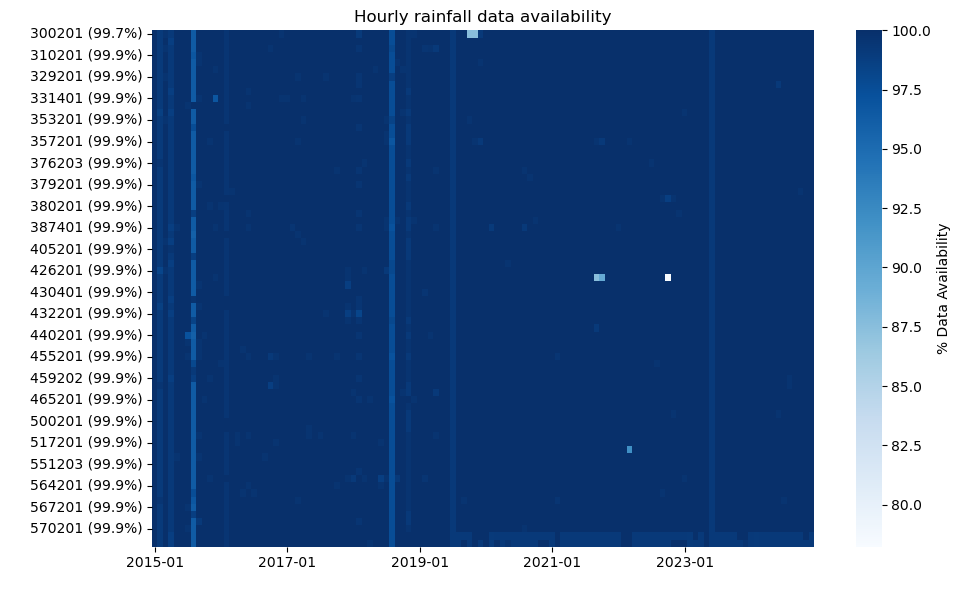

<Figure size 640x480 with 0 Axes>

In [8]:
rain_station_latlon_df = pd.read_csv('/g/data/qz03/wp3/data/tmd/obs/station_metadata.csv').dropna()
base_dir = '/g/data/qz03/wp3/data/tmd/obs/prec-3hr_2015-01-01_2024-12-31/'

files = [os.path.join(base_dir, station_name) for station_name in [station_csv for station_csv in os.listdir(base_dir) if 'prec' in station_csv] if os.path.isfile(os.path.join(base_dir, station_name))]
    
dfs = {f.split('/')[-1].replace('.csv',''): pd.read_csv(f) for f in files}
for df in dfs.values():
    df["time_step"] = (pd.to_datetime(df[['year', 'month', 'day']]) + pd.to_timedelta(df['time']))
df_list = [df['time_step'].dt.to_period('M').drop_duplicates() for df in dfs.values()]
all_months = pd.Index(pd.concat(df_list).drop_duplicates()).sort_values()

availability = pd.DataFrame(index=dfs.keys(), columns=all_months.astype(str))
for station, df in dfs.items():
    df['year_month'] = df['time_step'].dt.to_period('M')
    total_per_month = df.groupby('year_month').size()
    avail_per_month = df.groupby('year_month')['prec'].apply(lambda x: x.notna().sum())
    pct = (avail_per_month / total_per_month).reindex(all_months, fill_value=0) * 100
    availability.loc[station] = pct.values

availability.index = availability.index.str[-6:]
new_index = []
for station, df in dfs.items():
    total = len(df)
    available = df['prec'].notna().sum()
    percent = (available / total) * 100 if total > 0 else 0
    station_name = station[-6:]
    label = f"{station_name} ({percent:.1f}%)"
    new_index.append(label)

availability.index = new_index
availability.sort_index(inplace=True)
plt.figure(figsize=(10, len(dfs)*0.05 + 2.5))
sns.heatmap(availability.astype(float), cmap="Blues", cbar_kws={'label': '% Data Availability'}, xticklabels=24)
plt.title(f"Hourly rainfall data availability")
plt.ylabel(' ')
plt.xlabel(' ')
plt.tight_layout()
plt.show()
plt.clf()

In [5]:
rain_station_latlon_df = pd.read_csv('/g/data/qz03/wp3/data/tmd/obs/station_metadata.csv').dropna()
rain_station_df = pd.concat([pd.read_csv(f).assign(station_id=os.path.basename(f).split('_')[1].split('.')[0]) for f in glob.glob('/g/data/qz03/wp3/data/tmd/obs/prec-3hr_2015-01-01_2024-12-31/*.csv')], ignore_index=True)
rain_station_df["time_step"] = (pd.to_datetime(rain_station_df[['year', 'month', 'day']]) + pd.to_timedelta(rain_station_df['time']))
rain_station_df = rain_station_df.drop(columns=['year','month','day','time'])

In [7]:
pd.set_option('display.max_rows', None)

In [8]:
rain_station_latlon_df

,station_id,lat,lon
0,376202,16.702722,98.541833
1,436401,14.630972,102.721361
2,459201,13.355500,100.982194
3,379401,16.773944,101.245250
4,353201,17.452583,101.730694
5,303201,19.961444,99.881306
6,500201,11.835111,99.810361
7,300202,18.175167,97.933750
8,440201,13.688694,102.504167
9,570201,6.651528,100.086278


In [50]:
%%time
era_rain_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/tmd/reanalysis/ERA5/tp/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_daily_resampled = ((era_rain_hly.sortby("time").tp) * 1000).resample(time='D', offset=pd.Timedelta(hours=7)).sum() #(((era_rain_hly.sortby("time").tp)*1000).resample(time='D').sum())

CPU times: user 950 ms, sys: 102 ms, total: 1.05 s
Wall time: 1.03 s


In [51]:
%%time
era5_daily_resampled = era5_daily_resampled.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()

CPU times: user 4.9 s, sys: 925 ms, total: 5.82 s
Wall time: 7.74 s


In [39]:
rain_station_df

,prec,station_id,time_step
0,0.0,376202,2015-01-01 01:00:00
1,0.0,376202,2015-01-01 04:00:00
2,0.0,376202,2015-01-01 07:00:00
3,0.0,376202,2015-01-01 10:00:00
4,0.0,376202,2015-01-01 13:00:00
...,...,...,...
2104123,0.0,387401,2024-12-31 10:00:00
2104124,0.0,387401,2024-12-31 13:00:00
2104125,0.0,387401,2024-12-31 16:00:00
2104126,0.0,387401,2024-12-31 19:00:00


In [40]:
def grid_box_select(rain_reanalysis, model_res):
    rain = []
    for lat_offset, lon_offset in itertools.product([-model_res, 0, model_res], [-model_res, 0, model_res]):
        rain.append(rain_reanalysis.sel(lat=lat+lon_offset, lon=lon, method='nearest').compute().sortby("time"))
    rain_pt = xr.concat(rain, dim='z').mean('z').compute().sortby("time")
    return rain_pt

def point_select(rain_reanalysis):
    rain_pt = rain_reanalysis.sel(lat=lat, lon=lon, method='nearest').compute().sortby("time")
    return rain_pt

In [72]:
%%time
agg_df = []
for station_id in rain_station_latlon_df['station_id']:
    lat, lon = rain_station_latlon_df.loc[rain_station_latlon_df['station_id'] == station_id, ['lat', 'lon']].values[0]
    station_df = rain_station_df[rain_station_df['station_id'] == str(station_id)].copy()
    station_df['time_step'] = pd.to_datetime(station_df['time_step'])
    station_df = station_df.set_index('time_step').groupby('station_id')['prec'].resample('D').sum().reset_index()
    
    # ERA5 extract
    era5_pr = grid_box_select(era5_daily_resampled, 0.25) if grid_box_select_switch == True else point_select(era5_daily_resampled)

    # Convert to pandas Series and reset index
    era5_pr_series = era5_pr.to_series().reset_index(name='ERA5_PR').sort_values('time')

    # Merge station data with reanalysis data on time
    df = pd.merge_asof(station_df.sort_values('time_step'), era5_pr_series, left_on='time_step', right_on='time', direction='nearest').drop(columns='time')
    
    agg_df.append(df)

CPU times: user 13.9 s, sys: 688 ms, total: 14.6 s
Wall time: 13.8 s


In [73]:
full_rain_df = pd.concat(agg_df)

In [74]:
full_rain_df

,station_id,time_step,prec,ERA5_PR
0,376202,2015-01-01,0.0,8.326673e-14
1,376202,2015-01-02,0.0,8.326673e-14
2,376202,2015-01-03,0.0,8.326673e-14
3,376202,2015-01-04,0.0,1.148548e-03
4,376202,2015-01-05,0.0,8.326673e-14
...,...,...,...,...
3648,387401,2024-12-27,0.0,0.000000e+00
3649,387401,2024-12-28,0.0,0.000000e+00
3650,387401,2024-12-29,0.0,0.000000e+00
3651,387401,2024-12-30,0.0,0.000000e+00


In [75]:
mbe_era5 = {}
rmse_era5 = {}
for station_id in rain_station_latlon_df['station_id']:
    station_df = full_rain_df[full_rain_df['station_id'] == str(station_id)]
    mbe_era5[station_id]= (station_df['ERA5_PR']-station_df['prec']).mean()
    rmse_era5[station_id]=  np.sqrt(((station_df['ERA5_PR'] - station_df['prec']) ** 2).mean())

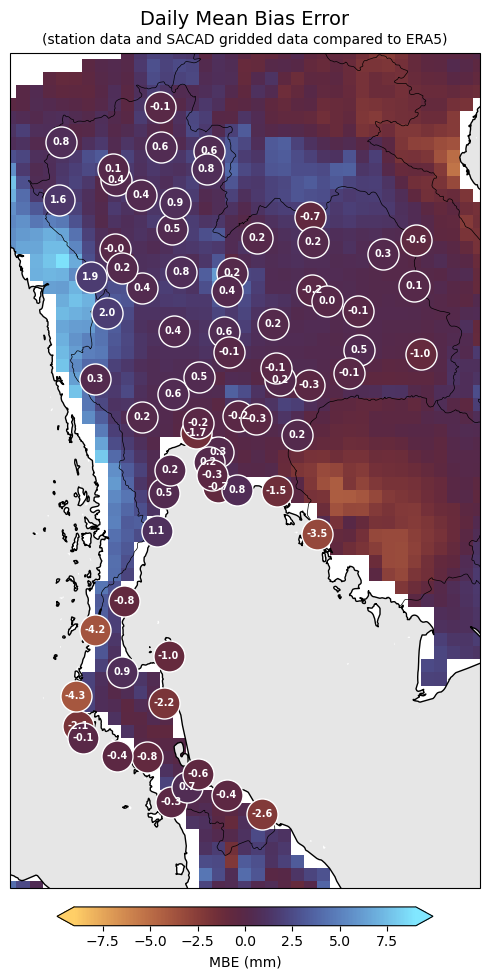

<Figure size 640x480 with 0 Axes>

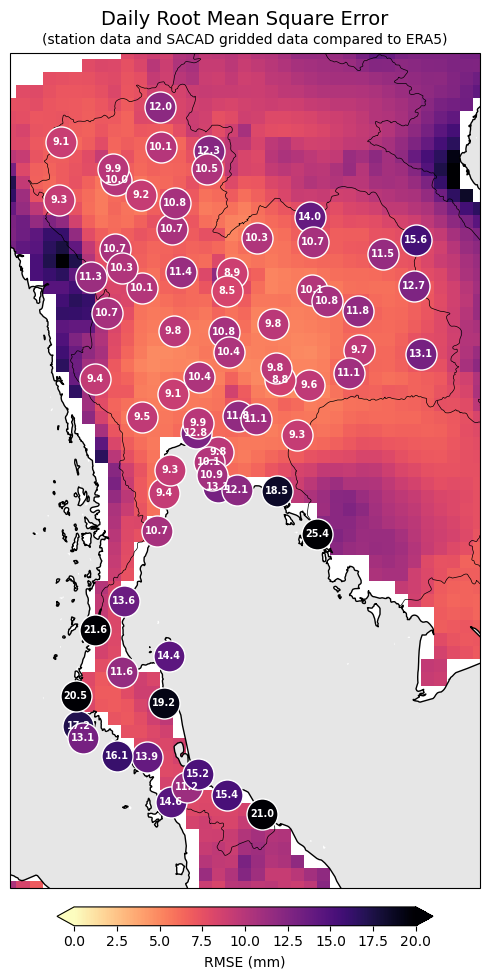

CPU times: user 5.24 s, sys: 1.93 s, total: 7.17 s
Wall time: 5.78 s


In [78]:
%%time
import matplotlib.cm as cm
import matplotlib.colors as colors
# import managua

era5_daily_resampled = era5_daily_resampled.sel(time=slice('1981-01-01','2017-12-31'))

stat_dict = {'mbe': mbe_era5, 'rmse': rmse_era5}

SACAD_rain_dly = xr.open_dataset('/g/data/qz03/wp3/data/bmkg/obs/wind-and-rain/rain-gridded-SACAD/rr_0.25deg_reg_v2.0_saobs.nc')\
                    .rename({'latitude': 'lat', 'longitude': 'lon'})
SACAD_rain_dly = SACAD_rain_dly.rr.interp_like(era5_daily_resampled)

# ----------------- MBE plot -----------------
fig, ax = plt.subplots(figsize=(5, 10), subplot_kw={'projection': ccrs.PlateCarree()})
plot_array = (era5_daily_resampled - SACAD_rain_dly).mean(dim='time')

# Define colormap and normalization for MBE
cmap = cm.get_cmap('managua')
norm = colors.Normalize(vmin=-10, vmax=10)

plot_item = plot_array.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), vmin=-9, vmax=9, cmap=cmap, add_colorbar=False)
cbar = fig.colorbar(plot_item, ax=ax, orientation='horizontal', pad=0.02, fraction=0.08, shrink=0.8, extend='both', label='MBE (mm)')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#e6e6e6', alpha=1)
ax.set_extent([domain_dict['thailand']['lon_min'], domain_dict['thailand']['lon_max'],
               domain_dict['thailand']['lat_min'], domain_dict['thailand']['lat_max']], crs=ccrs.PlateCarree())

# Overlay station MBE points with color mapped to value
for _, row in rain_station_latlon_df.iterrows():
    station_id = row['station_id']
    mbe_val = stat_dict['mbe'][station_id]
    ax.scatter(row['lon'], row['lat'], color=cmap(norm(mbe_val)), s=500, edgecolor='white', zorder=5)  # bigger dots
    ax.text(row['lon'], row['lat'], f"{mbe_val:.1f}", color='white', fontsize=7,
            ha='center', va='center', zorder=6, fontweight='bold')

ax.set_title(f"Daily Mean Bias Error", fontsize=14, pad=20)
fig.text(0.5, 0.963, "(station data and SACAD gridded data compared to ERA5)", ha='center', va='top', fontsize=10)
plt.tight_layout()
plt.show()
plt.clf()

# ----------------- RMSE plot -----------------
fig, ax = plt.subplots(figsize=(5, 10), subplot_kw={'projection': ccrs.PlateCarree()})
plot_array = np.sqrt(((era5_daily_resampled - SACAD_rain_dly) ** 2).mean(dim='time'))

cmap = cm.get_cmap('magma_r')
norm = colors.Normalize(vmin=0, vmax=20)

plot_item = plot_array.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), vmin=0, vmax=20, cmap=cmap, add_colorbar=False)
cbar = fig.colorbar(plot_item, ax=ax, orientation='horizontal', pad=0.02, fraction=0.08, shrink=0.8, extend='both', label='RMSE (mm)')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#e6e6e6', alpha=1)
ax.set_extent([domain_dict['thailand']['lon_min'], domain_dict['thailand']['lon_max'],
               domain_dict['thailand']['lat_min'], domain_dict['thailand']['lat_max']], crs=ccrs.PlateCarree())

# Overlay station RMSE points with color mapped to value
for _, row in rain_station_latlon_df.iterrows():
    station_id = row['station_id']
    rmse_val = stat_dict['rmse'][station_id]
    ax.scatter(row['lon'], row['lat'], color=cmap(norm(rmse_val)), s=500, edgecolor='white', zorder=5)  # bigger dots
    ax.text(row['lon'], row['lat'], f"{rmse_val:.1f}", color='white', fontsize=7,
            ha='center', va='center', zorder=6, fontweight='bold')

ax.set_title(f"Daily Root Mean Square Error", fontsize=14, pad=20)
fig.text(0.5, 0.963, "(station data and SACAD gridded data compared to ERA5)", ha='center', va='top', fontsize=10)
plt.tight_layout()
plt.show()